### Imports

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import math
from collections import Counter
from graphviz import Digraph
from IPython.display import Image
import os
import imageio.v2 as imageio
from PIL import Image
import random

Analizamos el dataset, por ejemplo Credit Amount es una variable continua, no nos sirve. Analizamos con un histograma su distribución y luego decidimos qué hacer. Así con todas las variables continuas o discretas pero con muchos valores.

Min Credit Amount: 250
Max Credit Amount: 18424


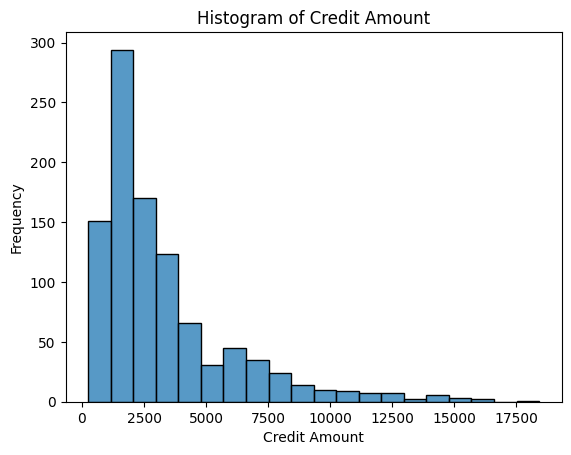

In [2]:
df = pd.read_csv('german_credit.csv')

# get the min and max of the column Credit Amount
min_credit_amount = df['Credit Amount'].min()
max_credit_amount = df['Credit Amount'].max()

print('Min Credit Amount:', min_credit_amount)
print('Max Credit Amount:', max_credit_amount)

# Histogram of Credit Amount
sns.histplot(df['Credit Amount'], bins=20)

plt.title('Histogram of Credit Amount')
plt.xlabel('Credit Amount')
plt.ylabel('Frequency')
plt.show()


### Discretización de variables continuas o variables discretas con muchos valores

In [3]:
# Discretizar "Credit Amount" en 4 intervalos (cuartiles) usando binning basado en frecuencia
df['Credit Amount'] = pd.qcut(df['Credit Amount'], q=4, labels=[0, 1, 2, 3]) # low, medium, high, very high

# Mostrar las primeras filas del dataset y la nueva columna
print(df['Credit Amount'].head())

# Distribución de los bins (conteo)
print(df['Credit Amount'].value_counts())

# Ver los intervalos de cada bin -> cambiar la primera linea de codigo para que no sobrescriba
# print(pd.qcut(df['Credit Amount'], q=4).value_counts())
# Credit Amount
# (249.999, 1365.5]     250
# (1365.5, 2319.5]      250
# (2319.5, 3972.25]     250
# (3972.25, 18424.0]    250

0    0
1    2
2    0
3    1
4    1
Name: Credit Amount, dtype: category
Categories (4, int64): [0 < 1 < 2 < 3]
Credit Amount
0    250
1    250
2    250
3    250
Name: count, dtype: int64


In [4]:
df['Duration of Credit (month)'] = pd.qcut(df['Duration of Credit (month)'], q=4, labels=[0, 1, 2, 3]) # short, medium, long, very_long

# Mostrar las primeras filas del dataset y la nueva columna
print(df['Duration of Credit (month)'].head())

# Distribución de los bins (conteo)
print(df['Duration of Credit (month)'].value_counts())

# Ver los intervalos de cada bin -> cambiar la primera linea de codigo para que no sobrescriba
# print(pd.qcut(df['Duration of Credit (month)'], q=4).value_counts())
# Duration of Credit (month)
# (3.999, 12.0]    359
# (24.0, 72.0]     230
# (18.0, 24.0]     224
# (12.0, 18.0]     187

0    1
1    0
2    0
3    0
4    0
Name: Duration of Credit (month), dtype: category
Categories (4, int64): [0 < 1 < 2 < 3]
Duration of Credit (month)
0    359
3    230
2    224
1    187
Name: count, dtype: int64


In [5]:
# Calcular el total de registros
total_records = len(df)

# Ver la distribución de "Purpose"
purpose_counts = df['Purpose'].value_counts()
print(purpose_counts)

# Definir un umbral del 5% del total de registros
threshold = 0.05 * total_records
print('Threshold:', threshold)

# Agrupar las categorías que tienen un conteo menor o igual al 5% en "Otros"
df['Purpose'] = df['Purpose'].apply(lambda x: x if purpose_counts[x] > threshold else 11) # 11 es la categoría "Otros"

# Mostrar la nueva distribución
print(df['Purpose'].value_counts())

Purpose
3     280
0     234
2     181
1     103
9      97
6      50
5      22
10     12
4      12
8       9
Name: count, dtype: int64
Threshold: 50.0
Purpose
3     280
0     234
2     181
11    105
1     103
9      97
Name: count, dtype: int64


# ID3

In [6]:
# Definición de la clase Node
class Node:
    def __init__(self, attribute=None, value=None, is_leaf=False, majority_class=None):
        self.attribute = attribute  # Atributo para dividir en este nodo
        self.children = {}          # Diccionario de hijos: valor del atributo -> nodo hijo
        self.value = value          # Clase si es un nodo hoja
        self.is_leaf = is_leaf      # Indicador de nodo hoja
        self.majority_class = majority_class  # Clase mayoritaria en este nodo

    def predict(self, sample):
        if self.is_leaf:
            return self.value
        else:
            attribute_value = sample.get(self.attribute)
            child = self.children.get(attribute_value)
            if child is not None:
                return child.predict(sample)
            else:
                # Si el valor del atributo no se vio durante el entrenamiento
                # Devolvemos la clase mayoritaria en este nodo
                return self.majority_class

# Definición de la clase DecisionTreeBuilder
class DecisionTreeBuilder:
    def __init__(self, target_attribute=None, enable_tree_image=False):
        self.root = None
        self.target_attribute = target_attribute
        self.enable_tree_image = enable_tree_image  # Flag para generar imagen del árbol

    def entropy(self, data):
        target_values = data[self.target_attribute]
        counts = target_values.value_counts()
        total = len(target_values)
        ent = 0
        for count in counts:
            p = count / total
            ent -= p * math.log2(p)
        return ent

    def information_gain(self, data, attribute):
        total_entropy = self.entropy(data)
        values = data[attribute].unique()
        weighted_entropy = 0
        total = len(data)
        for value in values:
            subset = data[data[attribute] == value]
            weight = len(subset) / total
            subset_entropy = self.entropy(subset)
            weighted_entropy += weight * subset_entropy
        gain = total_entropy - weighted_entropy
        return gain

    def id3(self, data, attributes, parent_node=None, parent_value=None):
        target_values = data[self.target_attribute]
        # Si todas las clases son iguales, devolver un nodo hoja
        if len(target_values.unique()) == 1:
            majority_class = target_values.iloc[0]
            leaf_node = Node(value=majority_class, is_leaf=True, majority_class=majority_class)
            return leaf_node
        # Si no hay más atributos, devolver un nodo hoja con la clase mayoritaria
        if len(attributes) == 0:
            majority_value = target_values.mode()[0]
            leaf_node = Node(value=majority_value, is_leaf=True, majority_class=majority_value)
            return leaf_node
        # Calcular la clase mayoritaria en este nodo
        majority_class = target_values.mode()[0]
        # Seleccionar el mejor atributo
        gains = {attribute: self.information_gain(data, attribute) for attribute in attributes}
        best_attribute = max(gains, key=gains.get)
        node = Node(attribute=best_attribute, majority_class=majority_class)
        # Para cada valor posible del mejor atributo, crear subárboles
        values = data[best_attribute].unique()
        for value in values:
            subset = data[data[best_attribute] == value]
            if subset.empty:
                # Si el subconjunto está vacío, crear un nodo hoja con la clase mayoritaria
                leaf_node = Node(value=majority_class, is_leaf=True, majority_class=majority_class)
                node.children[value] = leaf_node
            else:
                new_attributes = attributes.copy()
                new_attributes.remove(best_attribute)
                child_node = self.id3(subset, new_attributes)
                node.children[value] = child_node
        return node

    def build_tree(self, data, attributes):
        self.root = self.id3(data, attributes)
        if self.enable_tree_image:
            self.generate_tree_image()
        return self.root

    def predict(self, data):
        predictions = []
        for _, sample in data.iterrows():
            prediction = self.root.predict(sample)
            predictions.append(prediction)
        return predictions

    def generate_tree_image(self, filename='decision_tree'):
        dot = self.generate_graphviz(self.root)
        dot.render(filename, format='png', cleanup=True)

    def generate_graphviz(self, node, dot=None, parent=None, edge_label=None):
        if dot is None:
            dot = Digraph()
        node_id = str(id(node))
        if node.is_leaf:
            dot.node(name=node_id, label='Leaf: ' + str(node.value), shape='box')
        else:
            dot.node(name=node_id, label=str(node.attribute))
        if parent is not None:
            dot.edge(str(id(parent)), node_id, label=str(edge_label))
        if not node.is_leaf:
            for value, child in node.children.items():
                self.generate_graphviz(child, dot, node, value)
        return dot

### Util Functions

In [8]:
# Función para calcular la precisión
def accuracy(y_true, y_pred):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    return np.mean(y_true == y_pred)

# Función para calcular la matriz de confusión
def confusion_matrix(y_true, y_pred):
    classes = np.unique(y_true)
    matrix = pd.DataFrame(0, index=classes, columns=classes)
    for true, pred in zip(y_true, y_pred):
        matrix.at[true, pred] += 1
    return matrix

# Random Forest

In [9]:
# Implementación del Random Forest
class RandomForest:
    def __init__(self, n_estimators=10, max_features=None, enable_tree_images=False):
        self.n_estimators = n_estimators  # Número de árboles en el bosque
        self.max_features = max_features  # Número máximo de atributos a considerar en cada árbol
        self.enable_tree_images = enable_tree_images  # Flag para generar imágenes de los árboles
        self.trees = []  # Lista para almacenar los árboles
        self.target_attribute = None

    def fit(self, data, target_attribute):
        self.target_attribute = target_attribute
        self.classes = data[target_attribute].unique()
        for i in range(self.n_estimators):
            # Muestra de bootstrap
            bootstrap_sample = data.sample(frac=1, replace=True, random_state=random.randint(0, 10000))
            # Seleccionar un subconjunto aleatorio de atributos
            if self.max_features is None:
                max_features = int(math.sqrt(len(data.columns) - 1))
            else:
                max_features = self.max_features
            attributes = [col for col in data.columns if col != target_attribute]
            selected_attributes = random.sample(attributes, min(max_features, len(attributes)))
            # Construir el árbol
            tree_builder = DecisionTreeBuilder(target_attribute=target_attribute, enable_tree_image=self.enable_tree_images)
            tree = tree_builder.build_tree(bootstrap_sample, selected_attributes)
            self.trees.append((tree_builder, selected_attributes))
            # Generar imagen del árbol
            if self.enable_tree_images:
                tree_filename = f'decision_tree_{i}'
                tree_builder.generate_tree_image(filename=tree_filename)
                # Puedes guardar o manejar las imágenes como prefieras

    def predict(self, data):
        predictions = []
        for _, sample in data.iterrows():
            votes = []
            for tree_builder, attributes in self.trees:
                # Filtrar la muestra para solo incluir los atributos que el árbol conoce
                sample_subset = sample[attributes]
                prediction = tree_builder.root.predict(sample_subset)
                votes.append(prediction)
            # Votación por mayoría
            final_prediction = max(set(votes), key=votes.count)
            predictions.append(final_prediction)
        return predictions

    def evaluate(self, data):
        y_true = data[self.target_attribute]
        y_pred = self.predict(data)
        acc = accuracy(y_true, y_pred)
        return acc, y_true, y_pred

## Train, Test & Visualize

Entrenando Random Forest con 1 árboles...
Precisión en entrenamiento: 0.7188
Precisión en prueba: 0.5800
Entrenando Random Forest con 5 árboles...
Precisión en entrenamiento: 0.7775
Precisión en prueba: 0.7250
Entrenando Random Forest con 10 árboles...
Precisión en entrenamiento: 0.7638
Precisión en prueba: 0.6950
Entrenando Random Forest con 20 árboles...
Precisión en entrenamiento: 0.8200
Precisión en prueba: 0.7300
Matriz de Confusión:
   0    1
0  8   50
1  4  138


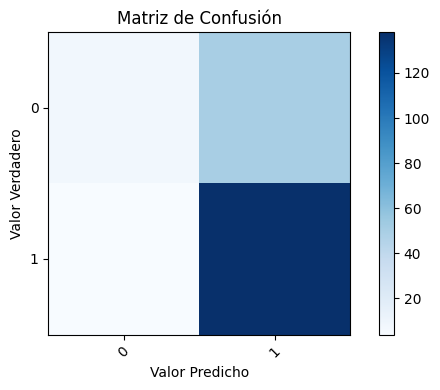

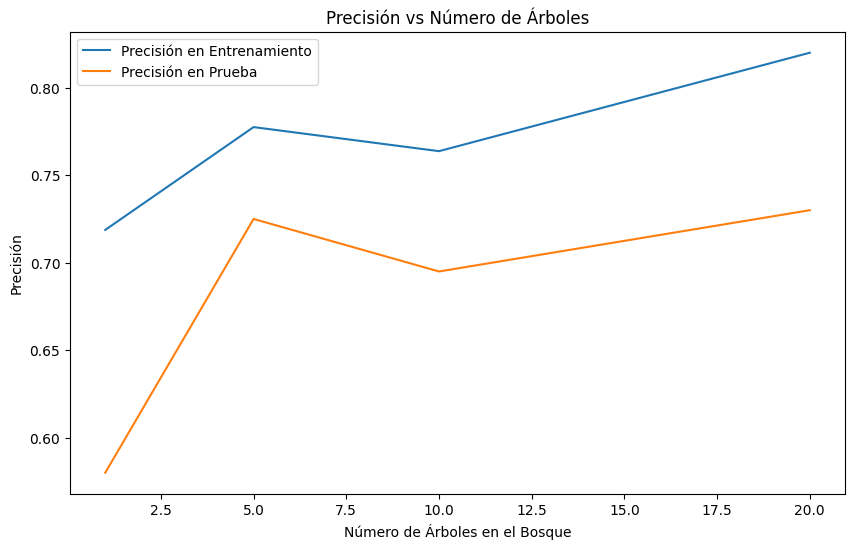

In [10]:
# Suponiendo que el atributo objetivo es 'Creditability' (asegúrate de que coincide con tu conjunto de datos)
target_attribute = 'Creditability'

# Usar todos los atributos excepto el atributo objetivo
attributes = [col for col in df.columns if col != target_attribute]

# Mezclar el conjunto de datos
data = df.sample(frac=1, random_state=42).reset_index(drop=True)

# Dividir en conjunto de entrenamiento y prueba (80% entrenamiento, 20% prueba)
train_size = int(0.8 * len(data))
train_data = data.iloc[:train_size]
test_data = data.iloc[train_size:]

# Parámetros para el Random Forest
n_estimators_list = [1, 5, 10, 20]  # Puedes ajustar esta lista para probar diferentes cantidades de árboles
max_features = None  # Si es None, utilizará sqrt(n_features)

# Almacenar las precisiones para graficar
train_accuracies = []
test_accuracies = []
estimators = []

for n_estimators in n_estimators_list:
    print(f"Entrenando Random Forest con {n_estimators} árboles...")
    rf = RandomForest(n_estimators=n_estimators, max_features=max_features, enable_tree_images=False)
    rf.fit(train_data, target_attribute)

    # Evaluar en entrenamiento
    train_acc, _, _ = rf.evaluate(train_data)
    train_accuracies.append(train_acc)

    # Evaluar en prueba
    test_acc, y_true, y_pred = rf.evaluate(test_data)
    test_accuracies.append(test_acc)

    estimators.append(n_estimators)

    print(f"Precisión en entrenamiento: {train_acc:.4f}")
    print(f"Precisión en prueba: {test_acc:.4f}")

    # Generar matriz de confusión para el último modelo
    if n_estimators == n_estimators_list[-1]:
        cm = confusion_matrix(y_true, y_pred)
        print("Matriz de Confusión:")
        print(cm)
        # Graficar la matriz de confusión
        plt.figure(figsize=(6, 4))
        plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
        plt.title('Matriz de Confusión')
        plt.colorbar()
        tick_marks = np.arange(len(cm.columns))
        plt.xticks(tick_marks, cm.columns, rotation=45)
        plt.yticks(tick_marks, cm.index)
        plt.xlabel('Valor Predicho')
        plt.ylabel('Valor Verdadero')
        plt.tight_layout()
        plt.show()

# Graficar la precisión en función de la cantidad de árboles
plt.figure(figsize=(10, 6))
plt.plot(estimators, train_accuracies, label='Precisión en Entrenamiento')
plt.plot(estimators, test_accuracies, label='Precisión en Prueba')
plt.xlabel('Número de Árboles en el Bosque')
plt.ylabel('Precisión')
plt.title('Precisión vs Número de Árboles')
plt.legend()
plt.show()